# VGG16 fine-tuning for defect detection

This section builds a VGG16 model with ImageNet weights, lets you choose any valid input shape (HxWx3), and fine-tune only the last layers you specify.

One classifier is trained, on patches extracted from the high-resolution frames. It is the single classifier every row of the defect detection pipeline is scored with: the low-resolution baseline, the eleven reconstructions and the high-resolution ceiling. Using one model is what makes those rows comparable, since a difference between two of them is then a difference between the images and not between two separately fitted networks.

The image-level partition is the one every other loader derives from the same seed, so the test frames here are the same ones the pipeline evaluates.

In [1]:
import os
import sys

import numpy as np

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))
from srlib.defect_detection.vgg16 import FineTunedVGG16
from srlib.dataset.loading import load_vgg16_dataset
from srlib.dataset.visualization import plot_classification_patches
from srlib.deep_learning.visualization import plot_vgg16_training_curves
from srlib.constants import (
    CLASS_LABELS_PATH,
    DL_RESULTS_DIR,
    HR_ROOT,
    LR_ROOT,
    VGG16_FIT_PARAMS,
    VGG16_SETUP_PARAMS,
    VGG_PATCH_SIZE,
    VGG_STRIDE,
)

In [2]:
# X -> HR image patches (model input)
# y -> class labels (target)
X_train, y_train, X_val, y_val, X_test, y_test = load_vgg16_dataset(
    HR_ROOT,
    LR_ROOT,
    CLASS_LABELS_PATH,
    patch_size=VGG_PATCH_SIZE,
    stride=VGG_STRIDE,
)


 VGG16 dataset | patch 48, stride 24
  images    798 indexed -> 798 kept -> 574 train / 64 val / 160 test


  patches   207,214 train / 23,104 val / 57,760 test   of 48 x 48 x 3
  memory    7.42 GB
  range     X [0.0000, 1.0000]
  classes   {0: 143317, 1: 144761}
  done in 9.6s



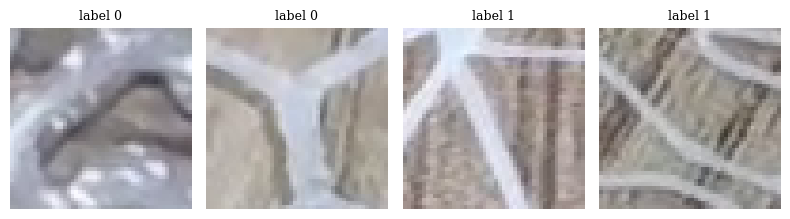

In [3]:
# What actually reaches the network: a crop of an HR frame and the class it
# inherits from the image it was cut out of.
_ = plot_classification_patches(X_train, y_train, count=4, seed=0)

In [4]:
model = FineTunedVGG16()
model.setup_model(
    input_shape=X_train.shape[1:],
    num_classes=np.unique(y_train).shape[0],
    **VGG16_SETUP_PARAMS,
)

Model: "vgg16_finetune"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 48, 48, 3)]       0         
                                                                 
 vgg16_preprocess (VGG16Prep  (None, 48, 48, 3)        0         
 rocessing)                                                      
                                                                 
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 gap (GlobalAveragePooling2D  (None, 512)              0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 256)            

In [5]:
# The head and the fine-tuning pass are separate training runs at different
# learning rates, so each returns its own history.
head_history, finetune_history = model.fit_two_phases(
    X_train, y_train,
    X_val, y_val,
    **VGG16_FIT_PARAMS,
)


Phase 1/2 - training the head only (131,842 trainable, 14,714,688 frozen)
Epoch 1/150
6476/6476 [==============================] - 111s 16ms/step - loss: 0.4690 - accuracy: 0.8292 - val_loss: 0.3295 - val_accuracy: 0.8645 - lr: 0.0010
Epoch 2/150
6476/6476 [==============================] - 91s 14ms/step - loss: 0.3765 - accuracy: 0.8454 - val_loss: 0.3165 - val_accuracy: 0.8706 - lr: 0.0010
Epoch 3/150
6476/6476 [==============================] - 93s 14ms/step - loss: 0.3721 - accuracy: 0.8474 - val_loss: 0.3158 - val_accuracy: 0.8750 - lr: 0.0010
Epoch 4/150
6476/6476 [==============================] - 95s 15ms/step - loss: 0.3679 - accuracy: 0.8490 - val_loss: 0.3130 - val_accuracy: 0.8721 - lr: 0.0010
Epoch 5/150
6476/6476 [==============================] - 93s 14ms/step - loss: 0.3655 - accuracy: 0.8502 - val_loss: 0.3094 - val_accuracy: 0.8775 - lr: 0.0010
Epoch 6/150
6476/6476 [==============================] - 93s 14ms/step - loss: 0.3631 - accuracy: 0.8509 - val_loss: 0.3148 

In [6]:
timestamp, run_dir, metrics = model.evaluate_and_save(
    X_test, y_test, head_history, finetune_history,
)


 VGG16 run 20260916_230224
  evaluating on the test partition
1805/1805 [==============================] - 13s 7ms/step - loss: 0.1350 - accuracy: 0.9559
Loss: 0.1350, Accuracy: 0.9559
Model saved to c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\VGG16\VGG16_20260916_230224\VGG16_20260916_230224.h5
  metrics    -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\VGG16\VGG16_20260916_230224\VGG16_20260916_230224_metrics.pkl
  summary    -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\VGG16\VGG16_20260916_230224\VGG16_20260916_230224_summary.txt
  epochs     -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\VGG16\VGG16_20260916_230224\VGG16_20260916_230224_epochs_data.txt
  done in 15

## Training curves

Training is solid with round markers and validation dashed with square ones, so the two splits stay apart where they overlap. The dotted horizontal line is the test score and the dash-dotted vertical line marks the epoch the backbone was unfrozen, where a step in the curve is expected. The loss panel is logarithmic because the two phases settle two orders of magnitude apart.

(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='Epoch', ylabel='Loss'>,
        <Axes: title={'center': 'Accuracy'}, xlabel='Epoch', ylabel='Accuracy'>],
       dtype=object))

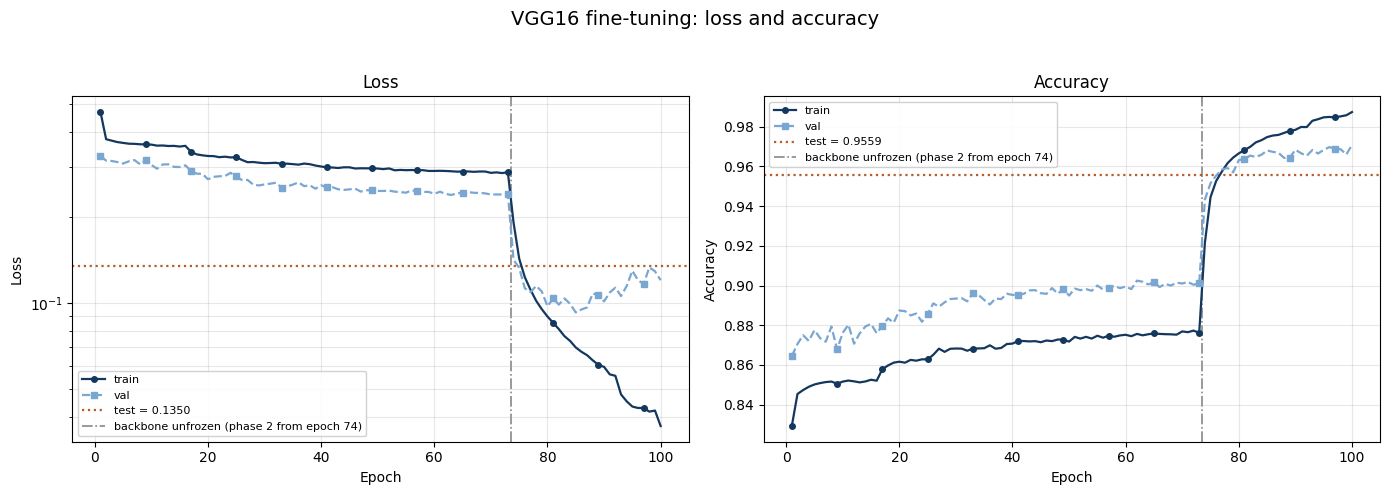

In [7]:
plot_vgg16_training_curves(metrics, save_path=DL_RESULTS_DIR)